In [351]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn import preprocessing
import sys
import matplotlib.pyplot as plt
import timeit
import math

import time
# from time import time

import seaborn as sns
sns.set(style="darkgrid")

import numpy.random as nr

import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import SGDClassifier, Perceptron
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, train_test_split

from sklearn.ensemble import RandomForestClassifier as RF
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPRegressor
#from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

%matplotlib inline
#%matplotlib notebook

In [352]:
# pca = PCA(random_state= '42')
# pca.fit(num_df)
# plt.plot(pca.explained_variance_ratio_)
nr.seed = 42

https://github.com/adomakor412/MachineLearning_DataMining/blob/master/HW/HW2/hw2_problem4.ipynb

In [353]:
#pd.read_csv?

In [354]:
data = pd.read_csv("dataDropped_from_162by127_to_157rowsby84columns.csv", sep=";")
#data#.head()

In [355]:
#data.loc[1]
#data.iloc[1]
#data.loc?

In [356]:
#data.columns

In [357]:
dfexp = data[data.columns[1:]]
#dfexp 

In [358]:
dfexp.index = range(4, 161)

In [359]:
dfexp

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,41.5,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.000
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.2,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.000
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.8,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.000
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,105.3,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.000
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.8,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,47.9,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.000
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,50.4,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867
158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,30.8,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.000
159,32.0,821.0,16.0,27.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,31.4,27.4,29.0,99.73,218.76,318.49,498.65,0.639,318.49,1794.000


In [360]:
# df_Target = dfexp[dfexp['97']/2 >= dfexp['124']]
df_Target = dfexp[dfexp['76'] >= dfexp['126']]
df_Target

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,41.5,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.0
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.2,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.0
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.8,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.0
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,105.3,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.0
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.8,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,152.0,808.0,43.0,45.0,1.0,375.0,375.0,750.0,281250.0,375.0,...,87.0,83.0,84.6,375.24,147.88,523.12,1876.18,0.279,523.12,1143.0
155,153.0,809.0,43.0,44.0,1.0,375.0,200.0,750.0,281250.0,375.0,...,87.0,83.0,84.6,200.13,249.55,449.68,1000.63,0.449,449.68,1603.0
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,47.9,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.0
158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,30.8,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.0


In [361]:
df_Target.index.to_list

<bound method IndexOpsMixin.tolist of Index([  4,   5,   6,   7,   8,  11,  12,  13,  14,  15,
       ...
       149, 150, 151, 152, 153, 154, 155, 156, 158, 159],
      dtype='int64', length=151)>

In [362]:
listTargetIndex = list(df_Target.index)
#listTargetIndex

In [363]:
dfexp['Target'] = 0

In [364]:
# for i in listTargetIndex:
#     dfexp['Target'].iloc[i] = 1
#Try using conditional indices]

'''Define as passed with conventional 1 being true

Cannot do defining a new column and conditional dependencies in one step- 
start with new column first!

utilize numpy to handle one of the dynamic methods
'''
dfexp['Target'] = np.where(dfexp['76'] < dfexp['126'], 0, 1)
dfexp

,1,2,3,4,5,6,7,8,15,16,...,119,120,121,122,123,124,125,126,127,Target
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.000,1
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.000,1
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.000,1
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.000,1
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.000,1
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867,0
158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.000,1
159,32.0,821.0,16.0,27.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,27.4,29.0,99.73,218.76,318.49,498.65,0.639,318.49,1794.000,1


In [365]:
# dfexp.iloc[listTargetIndex]
dfexp[dfexp['Target']==1]

,1,2,3,4,5,6,7,8,15,16,...,119,120,121,122,123,124,125,126,127,Target
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.0,1
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.0,1
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.0,1
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.0,1
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,152.0,808.0,43.0,45.0,1.0,375.0,375.0,750.0,281250.0,375.0,...,83.0,84.6,375.24,147.88,523.12,1876.18,0.279,523.12,1143.0,1
155,153.0,809.0,43.0,44.0,1.0,375.0,200.0,750.0,281250.0,375.0,...,83.0,84.6,200.13,249.55,449.68,1000.63,0.449,449.68,1603.0,1
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.0,1
158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.0,1


In [366]:
dfexp[dfexp['Target']==0]

,1,2,3,4,5,6,7,8,15,16,...,119,120,121,122,123,124,125,126,127,Target
9,5.0,40.0,2.0,35.0,1.0,300.0,300.0,1000.0,300000.0,500.0,...,28.0,29.6,250.76,111.61,362.37,1253.79,0.289,362.37,0.734,0
10,6.0,42.0,8.0,36.0,1.0,300.0,300.0,1000.0,300000.0,500.0,...,34.0,35.6,275.00,111.61,386.61,1375.00,0.281,386.61,0.723,0
21,17.0,213.0,9.0,145.0,1.0,250.0,80.0,400.0,59200.0,200.0,...,30.1,31.7,28.42,105.40,133.82,142.09,0.942,133.82,0.916,0
137,132.0,660.0,34.0,23.0,0.0,457.2,457.2,870.0,397741.0,435.0,...,121.3,122.9,641.51,245.58,887.09,3207.54,0.277,887.09,0.845,0
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867,0
160,147.0,874.0,41.0,17.0,1.0,300.0,300.0,450.0,135000.0,225.0,...,16.6,18.2,85.03,243.79,328.82,425.14,0.773,328.82,0.985,0


In [367]:
dfexp[dfexp.columns[:-1]]

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,41.5,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.000
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.2,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.000
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.8,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.000
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,105.3,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.000
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.8,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,47.9,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.000
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,50.4,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867
158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,30.8,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.000
159,32.0,821.0,16.0,27.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,31.4,27.4,29.0,99.73,218.76,318.49,498.65,0.639,318.49,1794.000


In [368]:
# scaler = StandardScaler()
# standardized_features = scaler.fit_transform(dfexp)
# standardized_features

scaler = StandardScaler()
standardized_features = scaler.fit_transform(dfexp[dfexp.columns[:-1]])
standardized_features

array([[-1.72105355, -2.14908591, -1.9688346 , ..., -0.40770751,
        -0.82491838, -0.56068325],
       [-1.69898876, -2.13429062, -1.9688346 , ..., -0.4078356 ,
        -0.74361089, -0.64454978],
       [-1.67692397, -2.12935886, -1.9688346 , ..., -0.40775061,
        -0.68477363, -0.80205522],
       ...,
       [-1.03704509,  1.80125534, -0.52398724, ..., -0.40736633,
         0.98256227,  0.25139022],
       [-1.0149803 ,  1.8061871 , -0.52398724, ..., -0.4075483 ,
         0.57938694,  0.4784435 ],
       [ 1.52247045,  2.06757048,  1.73358676, ..., -0.40738788,
         0.6372716 , -3.1892137 ]])

In [369]:
# df_standard = pd.DataFrame(standardized_features)
# df_standard.index = dfexp.index
# df_standard.columns = dfexp.columns

df_standard = pd.DataFrame(standardized_features)
df_standard.index = dfexp.index
df_standard.columns = dfexp.columns[:-1]

In [370]:
df_standard

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
4,-1.721054,-2.149086,-1.968835,-0.354802,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,-0.332096,-0.332096,-0.332096,-0.725716,-0.498787,-0.681524,-0.725763,-0.407708,-0.824918,-0.560683
5,-1.698989,-2.134291,-1.968835,-0.444502,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,2.012806,2.012806,2.012806,-0.566462,-0.498787,-0.629092,-0.566421,-0.407836,-0.743611,-0.644550
6,-1.676924,-2.129359,-1.968835,-0.422077,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,1.677249,1.677249,1.677249,-0.586341,-0.448635,-0.591150,-0.586388,-0.407751,-0.684774,-0.802055
7,-1.654859,-2.124427,-1.968835,-0.399652,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,2.216537,2.216537,2.216537,-0.554820,-0.405199,-0.542187,-0.554779,-0.407712,-0.608846,-0.830693
8,-1.632794,-2.119495,-1.968835,-0.377227,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,2.036774,2.036774,2.036774,-0.565034,-0.498787,-0.628658,-0.565015,-0.407837,-0.742938,-0.859330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,1.235628,1.786460,1.191769,-1.677882,0.486025,-0.841859,0.100142,-0.772621,-0.703170,-0.585147,...,-0.076434,-0.076434,-0.076434,-0.380409,-0.464959,-0.537887,-0.380455,-0.407872,-0.602177,0.050929
157,1.257693,1.796324,1.191769,-1.655457,0.486025,-0.841859,0.100142,-0.772621,-0.703170,-0.585147,...,0.023434,0.023434,0.023434,-0.363275,-0.015704,-0.133461,-0.363300,-0.407435,0.024972,-3.189455
158,-1.037045,1.801255,-0.523987,-1.139680,0.486025,0.791178,-0.446278,1.484465,0.780059,0.641907,...,-0.759532,-0.759532,-0.759532,0.064405,0.521440,0.484055,0.064425,-0.407366,0.982562,0.251390
159,-1.014980,1.806187,-0.523987,-1.094830,0.486025,0.791178,-0.446278,1.484465,0.780059,0.641907,...,-0.735563,-0.735563,-0.735563,0.075058,0.224596,0.224061,0.075057,-0.407548,0.579387,0.478444


# How well can we classify those that fail below ACI shear from those that do not?

In [371]:
#dfexp[dfexp.columns[:-1]]

In [372]:
# scaler = StandardScaler()
# standardized_features = scaler.fit_transform(dfexp[dfexp.columns[:-1]])

# X=standardized_features
# y= dfexp['Target']

In [373]:
# #df_standard['Target']
# df_standard['Target'].unique()

In [374]:
# start = time.time()
# #heldout = [0.95, 0.90, 0.75, 0.50, 0.01] #works well for balanced dataset
# heldout = [0.75, 0.66, 0.50, 0.25, 0.01]
# rounds = 20

# classifiers = [
#     ("SGD", SGDClassifier(max_iter=100)),
#     ("ASGD", SGDClassifier(average=True)),
#     ("Perceptron", Perceptron()),
#     ("Passive-Aggressive I", PassiveAggressiveClassifier(loss='hinge',
#                                                          C=1.0, tol=1e-4)),
#     ("Passive-Aggressive II", PassiveAggressiveClassifier(loss='squared_hinge',
#                                                           C=1.0, tol=1e-4)),
#     ("SAG", LogisticRegression(solver='sag', tol=1e-1, C=1.e4 / X.shape[0]))
# ]

# xx = 1. - np.array(heldout)

# for name, clf in classifiers:
#     print("training %s" % name)
#     #rng = np.random.RandomState(42)
#     rng = 42
#     yy = []
#     for i in heldout:
#         yy_ = []
#         for r in range(rounds):
#             X_train, X_test, y_train, y_test = \
#                 train_test_split(X, y, test_size=i, random_state=rng)
#             clf.fit(X_train, y_train)
#             y_pred = clf.predict(X_test)
#             yy_.append(1 - np.mean(y_pred == np.array(y_test)))
#         yy.append(np.mean(yy_))
#     plt.plot(xx, yy, label=name)
# plt.title('Classification models:\nProportion trained vs. Test Error rate– Seeded')
# plt.legend(loc="upper right")
# plt.xlabel("Proportion train")
# plt.ylabel("Test Error Rate")
# #plt.savefig("Full_data_TestErrorRate_seed42")
# plt.show()
# end = time.time()
# print(end-start, 'seconds')

## Consider Cross Validation now

In [375]:
# start = time.time()

# rng = 42

# #kf = KFold(n_splits=5)
# kf = KFold(n_splits=5, random_state=rng, shuffle=True)
# kf.get_n_splits(X)
# #print(kf)

# kFolds = ['K_fold-1','K_fold-2','K_fold-3','K_fold-4','K_fold-5']
# rounds = 20
# count = 0


# for train_index, test_index in kf.split(X):
#      print("TRAIN:", train_index, "TEST:", test_index)
#      X_train, X_test = np.array(X)[np.array(train_index)], np.array(X)[np.array(test_index)]
#      y_train, y_test = np.array(y)[np.array(train_index)], np.array(y)[np.array(test_index)]
        
#      classifiers = [
#         ("SGD", SGDClassifier(max_iter=100)),
#         ("ASGD", SGDClassifier(average=True)),
#         ("Perceptron", Perceptron()),
#         ("Passive-Aggressive I", PassiveAggressiveClassifier(loss='hinge',
#                                                              C=1.0, tol=1e-4)),
#         ("Passive-Aggressive II", PassiveAggressiveClassifier(loss='squared_hinge',
#                                                               C=1.0, tol=1e-4)),
#         ("SAG", LogisticRegression(solver='sag', tol=1e-1, C=1.e4 / X.shape[0]))
#      ]
#      #count+=1

#      for name, clf in classifiers:
#          print("training %s" % name)
#          yy = []
#          for i in heldout:
#              yy_ = []
#              for r in range(rounds):
#                  clf.fit(X_train, y_train)
#                  y_pred = clf.predict(X_test)
#                  yy_.append(1 - np.mean(y_pred == np.array(y_test)))
#              yy.append(np.mean(yy_))
#              #plt.title(f"Cross Validation Test Error Rate: {i}% trained")
#          plt.plot(xx, yy, label=name)
#          #plt.plot(heldout, yy, label=name)
#      plt.title(f"Cross Validation for {kFolds[count]}– Seeded")
#      plt.legend(loc="upper right")
#      plt.xlabel("Proportion trained")#
#      #plt.xlabel("Train-Test Index")
#      plt.ylabel("Test Error Rate")
#      #plt.savefig(f"{kFolds[count]}CrossValidationSeeded.png")
#      plt.show()
#      ##plt.savefig(f"CrossValidationTestErrorRate_{i}_percent_trained.png")
     
#      count+=1
# end = time.time()
# print(f"Time to run: {start-end} seconds")

https://github.com/adomakor412/capstone_AMS-pCal_MachineLearning/blob/master/ML_GOES_16_validation.ipynb

In [376]:
# df_ml = dfexp[dfexp.columns[:-1]]

In [377]:
# df_ml['124']

In [378]:
# df_ml_feature = dfexp[dfexp['Target']==0]
# df_ml_feature

In [379]:
#df_ml_feature.drop?

In [380]:
# df_ml_Target = df_ml_feature['97']/2
# df_ml_feature = df_ml_feature.drop(columns=['Target','124','97'])

In [381]:
# df_ml_feature

In [382]:
# df_ml_Target

In [383]:
# X_train, X_test, y_train, y_test = train_test_split(df_ml_feature, df_ml_Target,random_state=rng,test_size=0.25)
# regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_train, y_train)

In [384]:
# MAE_ML = []
# MSE_ML = []
# R2_ML = []
# R2_ML_train_test = []

In [385]:
#regr.score?

In [386]:
# train = regr.score(X_train,y_train)
# test = regr.score(X_test, y_test)

# R2_ML.append(test)
# R2_ML_train_test.append(train/test)

# prediction = regr.predict(X_test)
# errors = abs(prediction - y_test)

# MAE = round(np.mean(errors), 2)
# MAE_ML.append(MAE)

# MSE = mean_squared_error(prediction, y_test)
# MSE_ML.append(MSE)

# print(MAE_ML) 
# print(MSE_ML)
# print(R2_ML)
# print(R2_ML_train_test)

In [387]:
# y_test

In [388]:
# prediction

# Scaled regression

In [389]:
# MAE_ML_scaled = []
# MSE_ML_scaled  = []
# R2_ML_scaled  = []
# R2_ML_train_test_scaled = []

# scalerScale_ML = []
# scalerVar_ML = []                    
# scalerMean_ML = [] 

# X_trainScaled = X_train
# #Y_trainScaled = y_train

# scalerTrainX = StandardScaler()
# #scalerTrainY = StandardScaler()

# scalerTrainX.fit(X_trainScaled)
# #scalerTrainY.fit(Y_trainScaled)

# X_testScaled = scalerTrainX.transform(X_test)
# #Y_testScaled = scalerTrainY.transform(y_test)

# regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_trainScaled, y_train)

# train = regr.score(X_trainScaled,y_train)
# test = regr.score(X_testScaled, y_test)

# R2_ML_scaled.append(test)
# R2_ML_train_test_scaled.append(train/test)

# prediction = regr.predict(X_testScaled)
# errors = abs(prediction - y_test)

# MAE = round(np.mean(errors), 2)
# MAE_ML_scaled.append(MAE)

# MSE_scaled = mean_squared_error(prediction, y_test)
# MSE_ML_scaled.append(MSE)

# print(MAE_ML_scaled) 
# print(MSE_ML_scaled)
# print(R2_ML_scaled)
# print(R2_ML_train_test_scaled)

# # scalerScale_ML.append(scalerTrainY.scale_)
# # scalerVar_ML.append(scalerTrainY.var_)                 
# # scalerMean_ML.append(scalerTrainY.mean_)

# print(scalerScale_ML)
# print(scalerVar_ML)                 
# print(scalerMean_ML)


In [390]:
# y_test

In [391]:
# prediction, 

In [392]:
# regr.predict(X_trainScaled)

In [393]:
# y_train

In [394]:
# X_trainScaled

# Attempt with all data and target scaled

In [395]:
# df_ml_Target = df_standard['97']
# df_ml_feature = df_standard.drop(columns = ['97', '124', '127'])

In [396]:
# rng = 42
# X_train, X_test, y_train, y_test = train_test_split(df_ml_feature, df_ml_Target,random_state=rng,test_size=0.25)
# regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_train, y_train)

In [397]:
# MAE_ML_scaled = []
# MSE_ML_scaled  = []
# R2_ML_scaled  = []
# R2_ML_train_test_scaled = []

# scalerScale_ML = []
# scalerVar_ML = []                    
# scalerMean_ML = [] 

# X_trainScaled = X_train
# #Y_trainScaled = y_train

# scalerTrainX = StandardScaler()
# #scalerTrainY = StandardScaler()

# scalerTrainX.fit(X_trainScaled)
# #scalerTrainY.fit(Y_trainScaled)

# X_testScaled = scalerTrainX.transform(X_test)
# #Y_testScaled = scalerTrainY.transform(y_test)

# regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_trainScaled, y_train)

# train_scaled_score = regr.score(X_trainScaled,y_train)
# test_scaled_score = regr.score(X_testScaled, y_test)

# R2_ML_scaled.append(test_scaled_score)
# R2_ML_train_test_scaled.append(train_scaled_score/test_scaled_score)

# prediction = regr.predict(X_testScaled)
# errors = abs(prediction - y_test)

# MAE = round(np.mean(errors), 2)
# MAE_ML_scaled.append(MAE)

# MSE_scaled = mean_squared_error(prediction, y_test)
# MSE_ML_scaled.append(MSE_scaled)

# print(MAE_ML_scaled) 
# print(MSE_ML_scaled)
# print(R2_ML_scaled)
# print(R2_ML_train_test_scaled)

# # scalerScale_ML.append(scalerTrainY.scale_)
# # scalerVar_ML.append(scalerTrainY.var_)                 
# # scalerMean_ML.append(scalerTrainY.mean_)

# # print(scalerScale_ML)
# # print(scalerVar_ML)                 
# # print(scalerMean_ML)

# print(train_scaled_score)
# print(test_scaled_score)

In [398]:
# y_test

In [399]:
# prediction

https://github.com/adomakor412/Visualization/blob/master/PCA.ipynb

In [400]:
# data = pd.read_excel("preliminary_162x127.xlsx")
# data.head()

In [401]:
# indicators = df_standard.columns[:-1]
# #indicators = df_standard.drop(columns = ['97', 'Target']).columns
# indicators

In [402]:
# df_standard

In [403]:
#standardized_features

In [404]:
# # x = df_standard.drop(columns=['97', 'Target'])
# x = df_standard.drop(columns=['Target'])

In [431]:
x = df_standard
#x = df_standard[df_standard.columns[:-1]]

n_component = 20
random_state = 42
pca = PCA(n_components = n_component, random_state = random_state)
principalComponents = pca.fit_transform(x)
loading =np.transpose(pca.components_)
chart = pd.DataFrame(loading,columns =['PC 1','PC 2','PC 3','PC 4','PC 5','PC 6','PC 7','PC 8', 'PC 9','PC 10',
                                       'PC 11','PC 12','PC 13','PC 14','PC 15','PC 16','PC 17','PC 18','PC 19','PC 20'])

In [432]:
chart

,PC 1,PC 2,PC 3,PC 4,PC 5,PC 6,PC 7,PC 8,PC 9,PC 10,PC 11,PC 12,PC 13,PC 14,PC 15,PC 16,PC 17,PC 18,PC 19,PC 20
0,0.037231,0.041238,-0.075431,0.012919,0.311379,0.238188,-0.182632,-0.118134,0.161464,-0.084262,0.224781,-0.012140,-0.019004,-0.098649,-0.048120,0.124606,-0.034978,0.006923,0.029610,-0.013850
1,0.028844,0.035215,-0.074287,0.015866,0.275701,0.213207,-0.173148,-0.134778,0.237427,-0.149279,0.254534,-0.019927,0.079595,0.012661,-0.010277,0.016781,-0.103938,0.012805,0.100321,0.010503
2,0.052881,0.025407,-0.067073,-0.036973,0.241573,0.262188,-0.168919,-0.209541,0.147271,-0.130681,0.148088,-0.129881,-0.027047,0.013362,-0.052545,0.113208,-0.022179,-0.022214,-0.021277,-0.177154
3,-0.016478,0.088842,-0.154533,0.080174,0.034831,-0.019085,0.002504,-0.244900,-0.036744,-0.102025,-0.151197,0.372834,-0.129261,0.077583,-0.100654,-0.000180,0.291742,-0.075749,-0.053363,0.045894
4,0.029132,0.034211,-0.124395,0.059994,0.040658,-0.032983,0.166536,-0.098446,0.082221,-0.351440,0.131756,0.303757,0.008277,-0.054835,0.078840,0.164516,0.288355,-0.018143,0.269240,-0.030568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,0.172393,-0.083909,-0.057127,-0.097014,0.001259,0.006417,0.062298,-0.027046,0.071968,0.066844,-0.014969,-0.087184,0.058294,0.034356,-0.096765,0.073785,-0.027979,-0.030044,-0.080443,-0.106966
80,0.059364,-0.188031,0.086608,-0.000231,0.015516,0.136741,-0.030751,0.020969,0.199897,0.085553,-0.022512,0.037264,-0.149723,0.096239,-0.130549,-0.044400,0.047530,-0.049766,-0.149331,0.214770
81,0.116693,0.082260,-0.188447,-0.050556,-0.042904,-0.008780,-0.066073,0.203703,0.048519,0.043147,-0.093502,-0.037983,0.024417,0.135116,-0.214483,0.072998,0.039438,-0.032686,0.062160,-0.056070
82,0.157865,-0.133058,0.033783,-0.057642,0.029665,0.062730,0.051119,-0.035334,0.108700,0.073940,0.032377,0.048352,-0.007222,-0.017176,0.022797,-0.036948,-0.057413,0.022637,-0.062056,0.071603


In [424]:
principalComponents.shape

(157, 20)

In [425]:
PCA_col_20 = ['PC 1','PC 2','PC 3','PC 4','PC 5','PC 6','PC 7','PC 8', 'PC 9','PC 10',
            'PC 11','PC 12','PC 13','PC 14','PC 15','PC 16','PC 17','PC 18','PC 19','PC 20']
finalDF = pd.DataFrame(principalComponents, columns=PCA_col_20)

In [426]:
# Z=finalDf[['principal component 1','principal component 2']]
# X=finalDf[['principal component 1']]
# Y=finalDf[['principal component 2']]
# Z=chart[['PC 1','PC 2']]
# X=chart[['PC 1']]
# Y=chart[['PC 2']]
Z=finalDF[['PC 1','PC 2']]
X=finalDF[['PC 1']]
Y=finalDF[['PC 2']]


In [427]:
#chart.size
#chart#.loc[df_standard['Target'] == target]

In [428]:
# # Z=principalDf[['principal component 1','principal component 2']]
# # connectivity_centroid=KMeans(n_clusters=6)
# # connectivity_centroid.fit(Z)
# # y_kmeans = connectivity_centroid.predict(Z)
# #Z=chart[['PC 1','PC 2']]
# connectivity_centroid=KMeans(n_clusters=3)
# connectivity_centroid.fit(Z)
# y_kmeans = connectivity_centroid.predict(Z)

# # fig = plt.figure(figsize = (8,8))
# # ax = fig.add_subplot(1,1,1) 
# # ax.set_xlabel('Principal Component 1', fontsize = 15)
# # ax.set_ylabel('Principal Component 2', fontsize = 15)
# # ax.set_title('2 component PCA', fontsize = 20)
# # salaries = [0, 500, 1000]
# # colors = ['r', 'g', 'b']
# # for salary, color in zip(salaries,colors):
# #     indicesToKeep = finalDf['Salary'] >= salary
# #     ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
# #                , finalDf.loc[indicesToKeep, 'principal component 2']
# #                , c = color
# #                , s = 50)
# # ax.legend(['<=$500k', '<=$100k', '>$0.1M'])
# # ax.grid()

# # #plt.scatter(X, Y, c='b', s=50, cmap='viridis')

# # centers = connectivity_centroid.cluster_centers_
# # ax.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);

# # plt.scatter(X, Y, c='b', s=50, cmap='viridis')

# # centers = connectivity_centroid.cluster_centers_
# # ax.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);
# #plt.legend(['Centroid of fails ACI shear limit', 'Centroid of meets ACI shear limit'])

# fig = plt.figure(figsize = (8,8))
# ax = fig.add_subplot(1,1,1) 
# ax.set_xlabel('PC 1', fontsize = 15)
# ax.set_ylabel('PC 2', fontsize = 15)
# ax.set_title('ACI limit PCA comparison\n with Kmeans=3', fontsize = 20)
# targets = df_standard['Target'].unique()
# colors = ['r', 'g']
# for target, color in zip(targets,colors):
#     indicesToKeep = df_standard['Target'] == target
#     ax.scatter(finalDF.loc[finalDF.index[indicesToKeep], 'PC 1']
#                , finalDF.loc[finalDF.index[indicesToKeep], 'PC 2']
#                , c = color
#                , s = 50)
# #ax.legend(['Fails ACI shear limit', 'Meets ACI shear limit'])
# ax.grid()

# centers = connectivity_centroid.cluster_centers_
# ax.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);
# #ax.scatter(centers[:, 0], centers[:, 1], c='purple', s=200, alpha=0.5);
# #ax.legend(['Fails ACI shear limit', 'Meets ACI shear limit','Centroids'])
# ax.legend(['Fails ACI shear limit', 'Meets ACI shear limit',
#            'Centroid of 3 Kmeans'])

# #plt.savefig(f"ACI_limit_PCA_centroid_Comparison_3Kmeans.png")

# Kmeans 2 with All data comparison scaled

In [429]:
Z=finalDF[['PC 1','PC 2']]
connectivity_centroid=KMeans(n_clusters=2)
connectivity_centroid.fit(Z)
y_kmeans = connectivity_centroid.predict(Z)

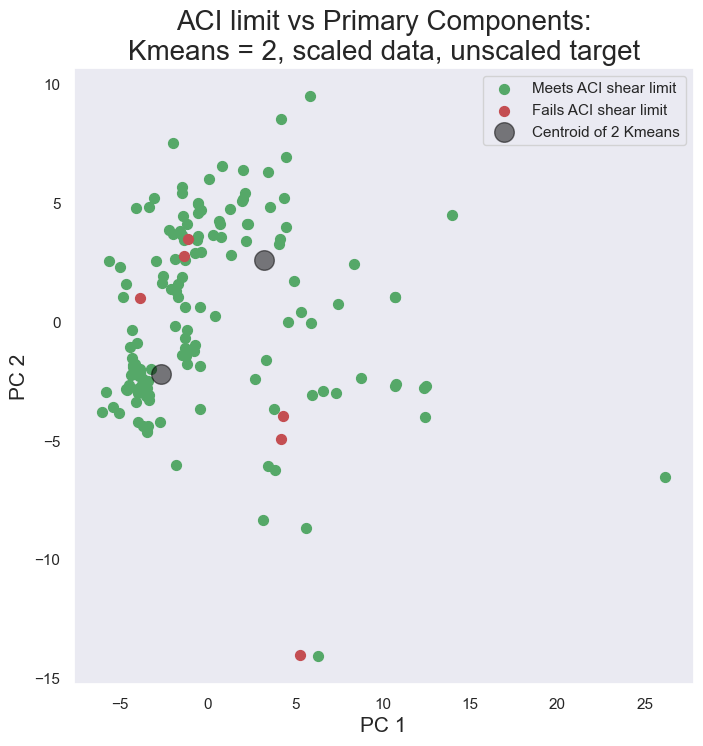

In [430]:
varTitle = "Kmeans = 2, scaled data, unscaled target"
x = df_standard

#varTitle = "Kmeans = 2, unscaled data"
#x = dfexp

fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('PC 1', fontsize = 15)
ax.set_ylabel('PC 2', fontsize = 15)
ax.set_title(f'ACI limit vs Primary Components:\n{varTitle}', fontsize = 20)

#targets = x['Target'].unique()
targets = dfexp['Target'].unique()
colors = ['g', 'r']
for target, color in zip(targets,colors):
    #indicesToKeep = x['Target'] == target
    indicesToKeep = dfexp['Target'] == target
    ax.scatter(finalDF.loc[finalDF.index[indicesToKeep], 'PC 1']
               , finalDF.loc[finalDF.index[indicesToKeep], 'PC 2']
               , c = color
               , s = 50
               #, alpha=0.5
               )
#ax.legend(['Fails ACI shear limit', 'Meets ACI shear limit'])
ax.grid()

centers = connectivity_centroid.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);
#ax.scatter(centers[:, 0], centers[:, 1], c='purple', s=200, alpha=0.5);
#ax.legend(['Fails ACI shear limit', 'Meets ACI shear limit','Centroids'])
ax.legend(['Meets ACI shear limit','Fails ACI shear limit', 'Centroid of 2 Kmeans'])

plt.savefig(f"ACI_limit_{varTitle}.png")

# # Kmeans 2 with All data comparison unscaled

In [433]:
x = dfexp[dfexp.columns[:-1]]

n_component = 20
random_state = 42
pca = PCA(n_components = n_component, random_state = random_state)
principalComponents = pca.fit_transform(x)
loading =np.transpose(pca.components_)
chart = pd.DataFrame(loading,columns =['PC 1','PC 2','PC 3','PC 4','PC 5','PC 6','PC 7','PC 8', 'PC 9','PC 10',
                                       'PC 11','PC 12','PC 13','PC 14','PC 15','PC 16','PC 17','PC 18','PC 19','PC 20'])
chart

,PC 1,PC 2,PC 3,PC 4,PC 5,PC 6,PC 7,PC 8,PC 9,PC 10,PC 11,PC 12,PC 13,PC 14,PC 15,PC 16,PC 17,PC 18,PC 19,PC 20
0,1.129839e-05,0.004090,0.005218,-0.015603,-0.012153,0.020943,0.023674,0.121679,-0.027656,0.142923,-0.001509,-0.067934,-0.014101,-0.032241,0.044435,0.035253,0.040185,-0.027451,0.008058,-0.148926
1,1.411082e-05,0.014425,0.015676,-0.076130,-0.080049,0.110339,0.133412,0.588105,-0.245978,0.621193,0.169681,-0.184480,-0.213729,-0.024991,-0.036955,0.009436,0.094171,0.000491,0.009518,0.053088
2,1.953261e-05,0.000822,0.001798,-0.000581,-0.003774,0.002833,0.003367,0.021358,-0.015543,0.037973,0.002191,-0.013150,-0.001857,-0.005917,-0.000209,0.001536,-0.002008,-0.003053,-0.003793,-0.060544
3,-1.171520e-04,0.003055,0.014635,-0.000195,-0.009664,0.028255,0.043757,-0.021761,0.017110,0.054493,-0.031579,0.073422,0.048709,-0.030258,-0.071375,0.075423,0.012356,-0.342203,0.485125,-0.091372
4,-1.245893e-07,0.000039,0.000093,0.000029,-0.000035,0.000181,0.000113,0.000425,-0.000133,-0.000110,-0.000120,-0.000066,-0.000682,0.000058,-0.001581,0.000831,0.000762,-0.001633,0.003551,0.001535
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,2.352970e-03,0.043704,0.079560,0.001489,-0.069103,-0.126770,-0.095843,0.163531,-0.275817,-0.164096,-0.069879,-0.038402,0.104971,-0.159229,0.415047,0.058328,-0.095225,0.193200,0.247079,-0.045560
80,2.949600e-03,-0.053240,-0.219821,-0.165528,-0.262351,-0.360250,-0.449712,0.233659,0.260221,0.215814,-0.136407,0.383942,0.200907,-0.220854,-0.016095,-0.000667,-0.090160,0.094704,0.037071,-0.069822
81,1.973299e-03,0.141569,0.816389,-0.401760,0.083542,-0.330556,-0.004942,-0.041319,0.129535,0.064300,0.064565,0.004381,0.002687,0.021574,-0.066282,-0.013832,0.020829,-0.021699,-0.034783,0.031362
82,1.610378e-03,0.017400,-0.031983,-0.024872,-0.039881,-0.082514,-0.029258,0.162114,-0.068007,-0.071785,-0.071179,0.085036,0.092369,-0.006075,-0.139356,-0.012480,0.112860,-0.127742,-0.222183,0.256946


In [434]:
PCA_col_20 = ['PC 1','PC 2','PC 3','PC 4','PC 5','PC 6','PC 7','PC 8', 'PC 9','PC 10',
            'PC 11','PC 12','PC 13','PC 14','PC 15','PC 16','PC 17','PC 18','PC 19','PC 20']
finalDF = pd.DataFrame(principalComponents, columns=PCA_col_20)

Z=finalDF[['PC 1','PC 2']]
X=finalDF[['PC 1']]
Y=finalDF[['PC 2']]

Z=finalDF[['PC 1','PC 2']]
connectivity_centroid=KMeans(n_clusters=2)
connectivity_centroid.fit(Z)
y_kmeans = connectivity_centroid.predict(Z)

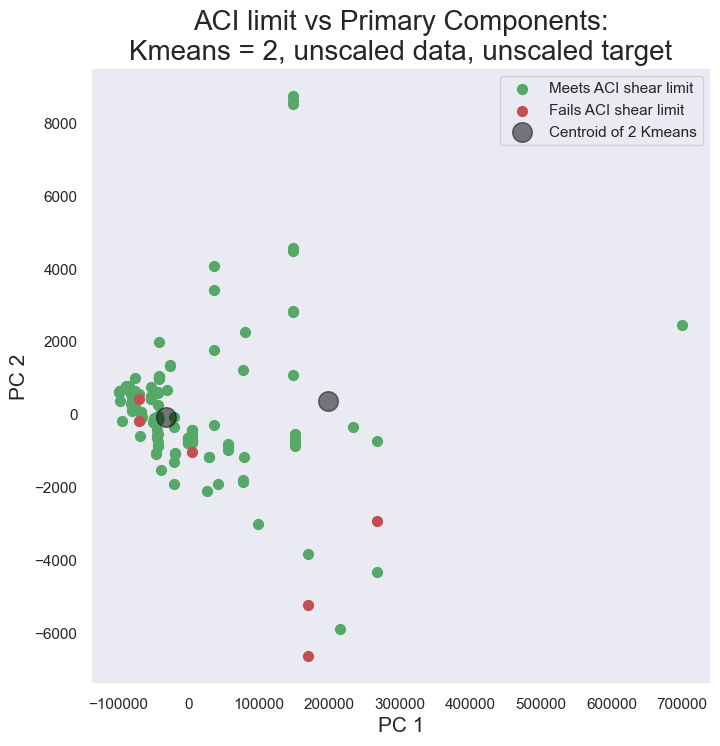

In [435]:
varTitle = "Kmeans = 2, unscaled data, unscaled target"
x = dfexp[dfexp.columns[:-1]]

fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('PC 1', fontsize = 15)
ax.set_ylabel('PC 2', fontsize = 15)
ax.set_title(f'ACI limit vs Primary Components:\n{varTitle}', fontsize = 20)

#targets = x['Target'].unique()
targets = dfexp['Target'].unique()
colors = ['g', 'r']
for target, color in zip(targets,colors):
    #indicesToKeep = x['Target'] == target
    indicesToKeep = dfexp['Target'] == target
    ax.scatter(finalDF.loc[finalDF.index[indicesToKeep], 'PC 1']
               , finalDF.loc[finalDF.index[indicesToKeep], 'PC 2']
               , c = color
               , s = 50
               #, alpha=0.5
               )
#ax.legend(['Fails ACI shear limit', 'Meets ACI shear limit'])
ax.grid()

centers = connectivity_centroid.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);
#ax.scatter(centers[:, 0], centers[:, 1], c='purple', s=200, alpha=0.5);
#ax.legend(['Fails ACI shear limit', 'Meets ACI shear limit','Centroids'])
ax.legend(['Meets ACI shear limit','Fails ACI shear limit', 'Centroid of 2 Kmeans'])

plt.savefig(f"ACI_limit_{varTitle}.png")

# Regress from Kmeans 2 with All data comparison

In [74]:
#KMeans

In [75]:
#connectivity_centroid

In [76]:
# y_kmeans

In [77]:
# y_kmeans.shape

In [78]:
# dfexp[dfexp['Target']==1]

In [79]:
# dfexp[dfexp['Target']==y_kmeans]

In [80]:
# df_regr_k2 = dfexp[dfexp['Target']!=y_kmeans]
# df_regr_k2

In [81]:
# list_match_index = [x for x in dfexp[dfexp['Target']==1].index for y in df_regr_k2.index if x == y]
# list_match_index


In [82]:
# len(list_match_index)

# Kmeans 2 of filtered data

In [83]:
# #min_class = min(y_kmeans.uni)
# count_set = {}
# for val in y_kmeans:
#     count_set[val] = count_set.get(val,0)+1
# min_kv = (math.inf,math.inf)
# for key in count_set.keys():
#     if min_kv[-1] > count_set[key]:
#         min_kv = (key, count_set[key])
# min_kv

In [84]:
# min_class = min_kv[0]

In [85]:
# dfexp[y_kmeans == min_class]

In [86]:
# dfexp_sub = dfexp[y_kmeans == 0]
# # dfexp_sub = dfexp_sub[dfexp_sub.columns[:-1]]
# # df_ml_Target = dfexp_sub[dfexp_sub.columns[-1]]

# df_ml_Target = dfexp_sub['97']/2
# df_ml_feature = dfexp_sub.drop(columns=['Target','124','97'])

In [87]:
# df_ml_feature

In [88]:
# rng = 42
# X_train, X_test, y_train, y_test = train_test_split(df_ml_feature, df_ml_Target,random_state=rng,test_size=0.25)
# regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_train, y_train)

In [89]:
# MAE_ML_scaled = []
# MSE_ML_scaled  = []
# R2_ML_scaled  = []
# R2_ML_train_test_scaled = []

# scalerScale_ML = []
# scalerVar_ML = []                    
# scalerMean_ML = [] 

# X_trainScaled = X_train
# #Y_trainScaled = y_train

# scalerTrainX = StandardScaler()
# #scalerTrainY = StandardScaler()

# scalerTrainX.fit(X_trainScaled)
# #scalerTrainY.fit(Y_trainScaled)

# X_testScaled = scalerTrainX.transform(X_test)
# #Y_testScaled = scalerTrainY.transform(y_test)

# regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_trainScaled, y_train)

# train_scaled_score = regr.score(X_trainScaled,y_train)
# test_scaled_score = regr.score(X_testScaled, y_test)

# R2_ML_scaled.append(test_scaled_score)
# R2_ML_train_test_scaled.append(train_scaled_score/test_scaled_score)

# prediction = regr.predict(X_testScaled)
# errors = abs(prediction - y_test)

# MAE = round(np.mean(errors), 2)
# MAE_ML_scaled.append(MAE)

# MSE_scaled = mean_squared_error(prediction, y_test)
# MSE_ML_scaled.append(MSE_scaled)

# print(MAE_ML_scaled) 
# print(MSE_ML_scaled)
# print(R2_ML_scaled)
# print(R2_ML_train_test_scaled)

# # scalerScale_ML.append(scalerTrainY.scale_)
# # scalerVar_ML.append(scalerTrainY.var_)                 
# # scalerMean_ML.append(scalerTrainY.mean_)

# # print(scalerScale_ML)
# # print(scalerVar_ML)                 
# # print(scalerMean_ML)

# print(train_scaled_score)
# print(test_scaled_score)

In [90]:
# y_test

In [91]:
# prediction

# Kmeans 2 of filtered data- all SCALED

In [92]:
# min_class

In [93]:
# dfexp_sub = df_standard[y_kmeans == min_class]

# df_ml_Target = dfexp_sub['97']/2
# df_ml_feature = dfexp_sub.drop(columns=['Target','124','97'])

In [94]:
# df_ml_Target

In [95]:
# df_ml_Target = df_ml_Target[df_ml_Target>0]

In [96]:
# df_ml_Target

In [97]:
# df_ml_feature.index
# # df_ml_feature[df_ml_feature.index,:]
# df_ml_feature = df_ml_feature.loc[df_ml_Target.index,:]

In [98]:
# rng = 42
# X_train, X_test, y_train, y_test = train_test_split(df_ml_feature, df_ml_Target,random_state=rng,test_size=0.25)
# regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_train, y_train)

# MAE_ML_scaled = []
# MSE_ML_scaled  = []
# R2_ML_scaled  = []
# R2_ML_train_test_scaled = []

# scalerScale_ML = []
# scalerVar_ML = []                    
# scalerMean_ML = [] 

# X_trainScaled = X_train
# #Y_trainScaled = y_train

# scalerTrainX = StandardScaler()
# #scalerTrainY = StandardScaler()

# scalerTrainX.fit(X_trainScaled)
# #scalerTrainY.fit(Y_trainScaled)

# X_testScaled = scalerTrainX.transform(X_test)
# #Y_testScaled = scalerTrainY.transform(y_test)

# regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_trainScaled, y_train)

# train_scaled_score = regr.score(X_trainScaled,y_train)
# test_scaled_score = regr.score(X_testScaled, y_test)

# R2_ML_scaled.append(test_scaled_score)
# R2_ML_train_test_scaled.append(train_scaled_score/test_scaled_score)

# prediction = regr.predict(X_testScaled)
# errors = abs(prediction - y_test)

# MAE = round(np.mean(errors), 2)
# MAE_ML_scaled.append(MAE)

# MSE_scaled = mean_squared_error(prediction, y_test)
# MSE_ML_scaled.append(MSE_scaled)

# print(MAE_ML_scaled) 
# print(MSE_ML_scaled)
# print(R2_ML_scaled)
# print(R2_ML_train_test_scaled)

# # scalerScale_ML.append(scalerTrainY.scale_)
# # scalerVar_ML.append(scalerTrainY.var_)                 
# # scalerMean_ML.append(scalerTrainY.mean_)

# # print(scalerScale_ML)
# # print(scalerVar_ML)                 
# # print(scalerMean_ML)

# print(train_scaled_score)
# print(test_scaled_score)

In [99]:
# prediction

In [100]:
# y_test

# Filter on data that pass ACI- scaled
## then check results against whether new prediction would pass test of others original data 

In [101]:
# count_set = {}
# for val in df_standard['Target']:#.unique():
#     count_set[val] = count_set.get(val,0)+1
# min_kv = (math.inf,math.inf)
# for key in count_set.keys():
#     if min_kv[-1] > count_set[key]:
#         min_kv = (key, count_set[key])
# min_kv

In [102]:
# count_set

In [103]:
# min_class = min_kv[0]

In [104]:
# dfexp_sub = df_standard[df_standard['Target'] == min_class]

# df_ml_Target = dfexp_sub['97']/2
# df_ml_feature = dfexp_sub.drop(columns=['Target','124','97'])

In [105]:
# rng = 42
# X_train, X_test, y_train, y_test = train_test_split(df_ml_feature, df_ml_Target,random_state=rng,test_size=0.25)
# regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_train, y_train)

# MAE_ML_scaled = []
# MSE_ML_scaled  = []
# R2_ML_scaled  = []
# R2_ML_train_test_scaled = []

# scalerScale_ML = []
# scalerVar_ML = []                    
# scalerMean_ML = [] 

# X_trainScaled = X_train
# #Y_trainScaled = y_train

# scalerTrainX = StandardScaler()
# #scalerTrainY = StandardScaler()

# scalerTrainX.fit(X_trainScaled)
# #scalerTrainY.fit(Y_trainScaled)

# X_testScaled = scalerTrainX.transform(X_test)
# #Y_testScaled = scalerTrainY.transform(y_test)

# regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_trainScaled, y_train)

# train_scaled_score = regr.score(X_trainScaled,y_train)
# test_scaled_score = regr.score(X_testScaled, y_test)

# R2_ML_scaled.append(test_scaled_score)
# R2_ML_train_test_scaled.append(train_scaled_score/test_scaled_score)

# prediction = regr.predict(X_testScaled)
# errors = abs(prediction - y_test)

# MAE = round(np.mean(errors), 2)
# MAE_ML_scaled.append(MAE)

# MSE_scaled = mean_squared_error(prediction, y_test)
# MSE_ML_scaled.append(MSE_scaled)

# print(MAE_ML_scaled) 
# print(MSE_ML_scaled)
# print(R2_ML_scaled)
# print(R2_ML_train_test_scaled)

# # scalerScale_ML.append(scalerTrainY.scale_)
# # scalerVar_ML.append(scalerTrainY.var_)                 
# # scalerMean_ML.append(scalerTrainY.mean_)

# # print(scalerScale_ML)
# # print(scalerVar_ML)                 
# # print(scalerMean_ML)

# print(train_scaled_score)
# print(test_scaled_score)

In [106]:
# df_ml_Target

# Filter on data that pass ACI- unscaled (avoids negative numbers)
## then check results against whether new prediction would pass test of others original data 

In [107]:
# dfexp

In [108]:
# count_set = {}
# for val in dfexp['Target']:#.unique():
#     count_set[val] = count_set.get(val,0)+1
# min_kv = (math.inf,math.inf)
# for key in count_set.keys():
#     if min_kv[-1] > count_set[key]:
#         min_kv = (key, count_set[key])
# min_kv

In [109]:
# min_class = min_kv[0]
# dfexp_sub = dfexp[dfexp['Target'] == min_class]

# df_ml_Target = dfexp_sub['97']/2
# df_ml_feature = dfexp_sub.drop(columns=['Target','124','97'])

In [110]:
# rng = 42
# X_train, X_test, y_train, y_test = train_test_split(df_ml_feature, df_ml_Target,random_state=rng,test_size=0.25)
# regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_train, y_train)

# MAE_ML_scaled = []
# MSE_ML_scaled  = []
# R2_ML_scaled  = []
# R2_ML_train_test_scaled = []

# scalerScale_ML = []
# scalerVar_ML = []                    
# scalerMean_ML = [] 

# X_trainScaled = X_train
# #Y_trainScaled = y_train

# scalerTrainX = StandardScaler()
# #scalerTrainY = StandardScaler()

# scalerTrainX.fit(X_trainScaled)
# #scalerTrainY.fit(Y_trainScaled)

# # X_testScaled = scalerTrainX.transform(X_test)
# # #Y_testScaled = scalerTrainY.transform(y_test)

# regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_trainScaled, y_train)

# train_scaled_score = regr.score(X_trainScaled,y_train)
# test_scaled_score = regr.score(X_testScaled, y_test)

# R2_ML_scaled.append(test_scaled_score)
# R2_ML_train_test_scaled.append(train_scaled_score/test_scaled_score)

# prediction = regr.predict(X_testScaled)
# errors = abs(prediction - y_test)

# MAE = round(np.mean(errors), 2)
# MAE_ML_scaled.append(MAE)

# MSE_scaled = mean_squared_error(prediction, y_test)
# MSE_ML_scaled.append(MSE_scaled)

# print(MAE_ML_scaled) 
# print(MSE_ML_scaled)
# print(R2_ML_scaled)
# print(R2_ML_train_test_scaled)

# # scalerScale_ML.append(scalerTrainY.scale_)
# # scalerVar_ML.append(scalerTrainY.var_)                 
# # scalerMean_ML.append(scalerTrainY.mean_)

# # print(scalerScale_ML)
# # print(scalerVar_ML)                 
# # print(scalerMean_ML)

# print(train_scaled_score)
# print(test_scaled_score)

In [111]:
# df_ml_Target

In [112]:
# df_ml_feature 

In [113]:
# df_ACI = dfexp[dfexp['Target']== min_class]
# df_ACI

In [114]:
# prediction

In [115]:
# y_test

In [116]:
# X_train

In [117]:
# y_train

# Filter on data that pass ACI- with Principal Component Loadings

## then check results against whether new prediction would pass test of others original data 

In [118]:
dim_anal_col = [94, 92, 72, 8, 26, 25, 96, 97, 123, 15, 88, 60, 117, 118, 119, 120, 62, 67, 66, 124]
dim_anal_col_str = ['8','15','25','26','60','62','66','67','72','88','92','94','96','97','117','118','119','120','123','124']
len(dim_anal_col_str)

20

In [119]:
df_Dim = dfexp[dim_anal_col_str]
df_Dim

,8,15,25,26,60,62,66,67,72,88,92,94,96,97,117,118,119,120,123,124
4,254.0,32258.0,203.2,203.2,39.46,31.57,3.39,0.0858,0.24,0.842,166.0,162.0,56.17,94.61,35.7,41.5,37.5,39.1,67.88,134.08
5,254.0,32258.0,198.1,198.1,95.17,76.14,5.11,0.0537,0.24,0.619,176.0,166.0,79.66,137.70,91.4,100.2,96.2,97.8,82.39,206.62
6,254.0,32258.0,198.1,198.1,87.18,69.74,4.96,0.0568,0.24,0.651,173.0,165.0,79.07,136.69,83.4,91.8,87.8,89.4,92.89,197.53
7,254.0,32258.0,198.1,198.1,99.99,80.00,5.20,0.0520,0.24,0.600,171.0,167.0,79.93,138.17,96.2,105.3,101.3,102.9,106.44,211.92
8,254.0,32258.0,198.1,198.1,95.74,76.59,5.12,0.0535,0.31,0.617,169.0,166.0,79.69,102.62,91.9,100.8,96.8,98.4,82.51,207.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,300.0,60000.0,260.0,260.0,45.50,36.40,3.76,0.0826,0.61,0.818,213.0,192.0,194.83,222.66,41.7,47.9,43.9,45.5,107.63,291.28
157,300.0,60000.0,260.0,260.0,47.85,38.28,3.90,0.0815,0.46,0.809,208.0,194.0,197.46,225.67,44.1,50.4,46.4,48.0,219.55,299.09
158,820.0,207100.0,719.4,719.4,29.30,23.44,2.71,0.0924,4.60,0.883,675.0,675.0,1009.81,524.58,25.5,30.8,26.8,28.4,390.44,493.81
159,820.0,207100.0,719.4,719.4,29.83,23.86,2.74,0.0920,5.22,0.881,676.0,676.0,1010.83,525.11,26.0,31.4,27.4,29.0,318.49,498.65


In [120]:
# df_Dim['Target'] = dfexp['Target']
# df_Dim

In [121]:
# df_ml_Target = df_Dim['97']/2
# df_ml_feature = df_Dim.drop(columns=['Target','124','97'])

In [122]:
# rng = 42
# X_train, X_test, y_train, y_test = train_test_split(df_ml_feature, df_ml_Target,random_state=rng,test_size=0.25)
# regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_train, y_train)

# MAE_ML_scaled = []
# MSE_ML_scaled  = []
# R2_ML_scaled  = []
# R2_ML_train_test_scaled = []

# scalerScale_ML = []
# scalerVar_ML = []                    
# scalerMean_ML = [] 

# X_trainScaled = X_train
# #Y_trainScaled = y_train

# scalerTrainX = StandardScaler()
# #scalerTrainY = StandardScaler()

# scalerTrainX.fit(X_trainScaled)
# #scalerTrainY.fit(Y_trainScaled)

# X_testScaled = scalerTrainX.transform(X_test)
# #Y_testScaled = scalerTrainY.transform(y_test)

# regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_trainScaled, y_train)

# train_scaled_score = regr.score(X_trainScaled,y_train)
# test_scaled_score = regr.score(X_testScaled, y_test)

# R2_ML_scaled.append(test_scaled_score)
# R2_ML_train_test_scaled.append(train_scaled_score/test_scaled_score)

# prediction = regr.predict(X_testScaled)
# errors = abs(prediction - y_test)

# MAE = round(np.mean(errors), 2)
# MAE_ML_scaled.append(MAE)

# MSE_scaled = mean_squared_error(prediction, y_test)
# MSE_ML_scaled.append(MSE_scaled)

# print(MAE_ML_scaled) 
# print(MSE_ML_scaled)
# print(R2_ML_scaled)
# print(R2_ML_train_test_scaled)

# # scalerScale_ML.append(scalerTrainY.scale_)
# # scalerVar_ML.append(scalerTrainY.var_)                 
# # scalerMean_ML.append(scalerTrainY.mean_)

# # print(scalerScale_ML)
# # print(scalerVar_ML)                 
# # print(scalerMean_ML)

# print(train_scaled_score)
# print(test_scaled_score)

https://www.thestructuralengineer.info/education/professional-examinations-preparation/calculation-examples/maximum-factored-vertical-shear

# Assumption recheck: V_u > V_c_ACI

In [123]:
df_Dim[df_Dim['97']>df_Dim['124']]

,8,15,25,26,60,62,66,67,72,88,92,94,96,97,117,118,119,120,123,124
11,800.0,277821.0,704.0,704.0,42.25,33.80,3.56,0.0843,8.00,0.831,620.0,611.0,2335.34,973.06,38.4,44.5,40.5,42.1,525.53,284.40
12,1450.0,830000.0,1369.0,1369.0,41.14,32.91,3.49,0.0849,44.32,0.835,1272.0,1272.0,12284.65,2932.03,37.3,43.3,39.3,40.9,2220.69,1090.62
23,387.4,110161.0,299.2,299.2,32.30,25.84,2.92,0.0903,2.01,0.871,257.0,257.0,357.25,390.69,28.5,34.0,30.0,31.6,340.18,248.35
24,387.4,110161.0,309.6,309.6,32.30,25.84,2.92,0.0903,2.08,0.871,288.0,267.0,371.73,406.53,28.5,34.0,30.0,31.6,122.43,257.00
27,400.0,86000.0,350.0,350.0,29.43,23.54,2.72,0.0923,1.33,0.882,318.0,318.0,261.99,216.08,25.6,31.0,27.0,28.6,142.85,186.46
28,400.0,86000.0,350.0,350.0,18.56,14.85,1.88,0.1013,1.33,0.926,302.0,302.0,248.66,205.08,14.8,19.5,15.5,17.1,163.99,144.40
30,500.0,104000.0,470.0,470.0,27.55,22.04,2.58,0.0937,3.74,0.890,407.0,379.0,678.12,452.08,23.8,29.0,25.0,26.6,178.39,161.04
31,500.0,104000.0,470.0,470.0,27.55,22.04,2.58,0.0937,1.93,0.890,407.0,379.0,678.12,467.67,23.8,29.0,25.0,26.6,178.39,161.04
82,350.0,50000.0,300.0,300.0,22.56,18.05,2.21,0.0978,1.17,0.910,258.0,257.0,135.68,129.22,18.8,23.8,19.8,21.4,71.44,115.12
83,350.0,41250.0,300.0,300.0,22.56,18.05,2.21,0.0978,0.97,0.910,269.0,257.0,135.68,129.22,18.8,23.8,19.8,21.4,59.93,57.56


# Assumption recheck, : V_u < V_c_ACI

In [124]:
df_Dim[df_Dim['97']<df_Dim['124']]

,8,15,25,26,60,62,66,67,72,88,92,94,96,97,117,118,119,120,123,124
4,254.0,32258.0,203.2,203.2,39.46,31.57,3.39,0.0858,0.24,0.842,166.0,162.0,56.17,94.61,35.7,41.5,37.5,39.1,67.88,134.08
5,254.0,32258.0,198.1,198.1,95.17,76.14,5.11,0.0537,0.24,0.619,176.0,166.0,79.66,137.70,91.4,100.2,96.2,97.8,82.39,206.62
6,254.0,32258.0,198.1,198.1,87.18,69.74,4.96,0.0568,0.24,0.651,173.0,165.0,79.07,136.69,83.4,91.8,87.8,89.4,92.89,197.53
7,254.0,32258.0,198.1,198.1,99.99,80.00,5.20,0.0520,0.24,0.600,171.0,167.0,79.93,138.17,96.2,105.3,101.3,102.9,106.44,211.92
8,254.0,32258.0,198.1,198.1,95.74,76.59,5.12,0.0535,0.31,0.617,169.0,166.0,79.69,102.62,91.9,100.8,96.8,98.4,82.51,207.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,750.0,281250.0,655.0,655.0,82.65,66.12,4.86,0.0588,7.38,0.669,605.0,587.0,1649.54,780.85,78.9,87.0,83.0,84.6,523.12,1876.18
155,750.0,281250.0,655.0,655.0,82.65,66.12,4.86,0.0588,7.38,0.669,593.0,587.0,1649.54,780.85,78.9,87.0,83.0,84.6,449.68,1000.63
156,300.0,60000.0,260.0,260.0,45.50,36.40,3.76,0.0826,0.61,0.818,213.0,192.0,194.83,222.66,41.7,47.9,43.9,45.5,107.63,291.28
157,300.0,60000.0,260.0,260.0,47.85,38.28,3.90,0.0815,0.46,0.809,208.0,194.0,197.46,225.67,44.1,50.4,46.4,48.0,219.55,299.09


# Assumption recheck, : F > V_ACI_cal

In [125]:
dfexp[dfexp['76'] >dfexp['126']]

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,41.5,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.0
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.2,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.0
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.8,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.0
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,105.3,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.0
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.8,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,152.0,808.0,43.0,45.0,1.0,375.0,375.0,750.0,281250.0,375.0,...,87.0,83.0,84.6,375.24,147.88,523.12,1876.18,0.279,523.12,1143.0
155,153.0,809.0,43.0,44.0,1.0,375.0,200.0,750.0,281250.0,375.0,...,87.0,83.0,84.6,200.13,249.55,449.68,1000.63,0.449,449.68,1603.0
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,47.9,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.0
158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,30.8,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.0


# Assumption recheck, : F < V_ACI_cal

In [126]:
dfexp[dfexp['76'] <dfexp['126']]

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
9,5.0,40.0,2.0,35.0,1.0,300.0,300.0,1000.0,300000.0,500.0,...,32.0,28.0,29.6,250.76,111.61,362.37,1253.79,0.289,362.37,0.734
10,6.0,42.0,8.0,36.0,1.0,300.0,300.0,1000.0,300000.0,500.0,...,38.0,34.0,35.6,275.00,111.61,386.61,1375.00,0.281,386.61,0.723
21,17.0,213.0,9.0,145.0,1.0,250.0,80.0,400.0,59200.0,200.0,...,34.1,30.1,31.7,28.42,105.40,133.82,142.09,0.942,133.82,0.916
137,132.0,660.0,34.0,23.0,0.0,457.2,457.2,870.0,397741.0,435.0,...,125.3,121.3,122.9,641.51,245.58,887.09,3207.54,0.277,887.09,0.845
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,50.4,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867
160,147.0,874.0,41.0,17.0,1.0,300.0,300.0,450.0,135000.0,225.0,...,20.6,16.6,18.2,85.03,243.79,328.82,425.14,0.773,328.82,0.985


In [127]:
df_ACI_311 = dfexp[dfexp['76'] <dfexp['126']]

In [128]:
df_ACI_311[['76','126']]

,76,126
9,265.86,362.37
10,279.50,386.61
21,123.69,133.82
137,760.63,887.09
157,190.46,219.55
160,326.27,328.82


# New Analysis- All columns

In [222]:
df_Train = dfexp[dfexp['76'] >dfexp['126']]
df_Input = df_Train.drop(columns=['126'])
#df_Output = dfexp['126']
df_Output = df_Train.loc[:,'126']

In [223]:
df_Input

,1,2,3,4,5,6,7,8,15,16,...,117,118,119,120,121,122,123,124,125,127
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,35.7,41.5,37.5,39.1,26.82,41.06,67.88,134.08,0.506,1286.0
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.4,100.2,96.2,97.8,41.32,41.06,82.39,206.62,0.399,1245.0
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,83.4,91.8,87.8,89.4,39.51,53.38,92.89,197.53,0.470,1168.0
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,96.2,105.3,101.3,102.9,42.38,64.05,106.44,211.92,0.502,1154.0
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.9,100.8,96.8,98.4,41.45,41.06,82.51,207.26,0.398,1140.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,152.0,808.0,43.0,45.0,1.0,375.0,375.0,750.0,281250.0,375.0,...,78.9,87.0,83.0,84.6,375.24,147.88,523.12,1876.18,0.279,1143.0
155,153.0,809.0,43.0,44.0,1.0,375.0,200.0,750.0,281250.0,375.0,...,78.9,87.0,83.0,84.6,200.13,249.55,449.68,1000.63,0.449,1603.0
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,41.7,47.9,43.9,45.5,58.26,49.37,107.63,291.28,0.369,1585.0
158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,25.5,30.8,26.8,28.4,98.76,291.68,390.44,493.81,0.791,1683.0


In [224]:
df_Output

4       67.88
5       82.39
6       92.89
7      106.44
8       82.51
        ...  
154    523.12
155    449.68
156    107.63
158    390.44
159    318.49
Name: 126, Length: 151, dtype: float64

In [225]:
#type(df_Output)

In [226]:
rng = 42
X_train, X_test, y_train, y_test = train_test_split(df_Input, df_Output,random_state=rng,test_size=0.25)
regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_train, y_train)

# MAE_ML_scaled = []
# MSE_ML_scaled  = []
# R2_ML_scaled  = []
# R2_ML_train_test_scaled = []

MAE_ML = []
MSE_ML  = []
R2_ML = []
R2_ML_train_test = []

scalerScale_ML = []
scalerVar_ML = []                    
scalerMean_ML = [] 

X_trainScaled = X_train
#Y_trainScaled = y_train

scalerTrainX = StandardScaler()
#scalerTrainY = StandardScaler()

scalerTrainX.fit(X_trainScaled)
#scalerTrainY.fit(Y_trainScaled)

#X_testScaled = scalerTrainX.transform(X_test)
#Y_testScaled = scalerTrainY.transform(y_test)

# regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_trainScaled, y_train)
regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_train, y_train)

# train_scaled_score = regr.score(X_trainScaled,y_train)
# test_scaled_score = regr.score(X_testScaled, y_test)

train_score = regr.score(X_train,y_train)
test_score = regr.score(X_test, y_test)

# R2_ML_scaled.append(test_scaled_score)
# R2_ML_train_test_scaled.append(train_scaled_score/test_scaled_score)

R2_ML.append(test_score)
R2_ML_train_test.append(train_score/test_score)

#prediction = regr.predict(X_testScaled)
prediction = regr.predict(X_test)
errors = abs(prediction - y_test)

MAE = round(np.mean(errors), 2)
# MAE_ML_scaled.append(MAE)
MAE_ML.append(MAE)

# MSE_scaled = mean_squared_error(prediction, y_test)
# MSE_ML_scaled.append(MSE_scaled)

MSE = mean_squared_error(prediction, y_test)
MSE_ML.append(MSE)

# print(MAE_ML_scaled) 
# print(MSE_ML_scaled)
# print(R2_ML_scaled)
# print(R2_ML_train_test_scaled)

print(MAE_ML) 
print(MSE_ML)
print(R2_ML)
print(R2_ML_train_test)

# scalerScale_ML.append(scalerTrainY.scale_)
# scalerVar_ML.append(scalerTrainY.var_)                 
# scalerMean_ML.append(scalerTrainY.mean_)

# print(scalerScale_ML)
# print(scalerVar_ML)                 
# print(scalerMean_ML)

# print(train_scaled_score)
# print(test_scaled_score)

print(train_score)
print(test_score)

[2834.71]
[9213838.955674749]
[-878.2354202248224]
[0.491105359235407]
-431.30612154277003
-878.2354202248224


In [227]:
y_test

83      57.56
25     121.02
89     188.07
88     120.79
151     62.19
38     156.97
85     193.97
71     182.74
62     172.40
92     222.88
52     311.49
18     107.81
43     163.53
15     317.17
26      83.73
145     65.57
121     78.16
154    523.12
63     183.23
141    123.66
36     156.97
91     222.88
33     220.39
140    107.04
131     80.15
150     72.47
118    117.99
74     167.04
105     97.25
37     156.97
29     343.14
22     105.15
132    419.24
17     156.61
134    287.81
58     174.93
73     160.38
34     322.06
Name: 126, dtype: float64

In [228]:
prediction

array([1735.87549694, 2661.99732089, 3336.39830542, 3326.89821652,
       1594.10236544, 2318.27686706, 3740.27712247, 3220.88403327,
       2544.6207239 , 3659.79526136, 2867.72799711, 2404.93413659,
       2316.09124656, 5200.28663249, 2262.35144717, 1907.93249066,
       2322.8282914 , 6596.82856195, 2573.70823974, 1576.58266425,
       2287.04657456, 3697.93480452, 4389.41696418, 1637.49266531,
       2956.21774959, 1556.56863599, 2233.72377642, 3237.20827297,
       2194.63053022, 2275.30690982, 2825.858417  , 2510.85987475,
       5024.30406093, 3949.17454933, 5575.98025029, 2305.66423092,
       3249.61845613, 4448.09057922])

In [229]:
df_pred = pd.DataFrame(prediction, columns = ['Prediction'], index =y_test.index)
df_pred

,Prediction
83,1735.875497
25,2661.997321
89,3336.398305
88,3326.898217
151,1594.102365
38,2318.276867
85,3740.277122
71,3220.884033
62,2544.620724
92,3659.795261


In [230]:
F_tested = dfexp.loc[y_test.index,'76']
F_tested

83      98.08
25     219.62
89     338.32
88     232.38
151     86.98
38     279.31
85     338.53
71     209.76
62     274.64
92     336.36
52     356.03
18     157.66
43     254.61
15     369.39
26     149.83
145    130.95
121    139.36
154    605.38
63     305.44
141    221.27
36     209.66
91     346.17
33     228.16
140    247.77
131    162.87
150    105.53
118    205.91
74     205.31
105    128.01
37     207.41
29     428.80
22     142.16
132    601.24
17     237.46
134    536.67
58     245.14
73     219.55
34     388.29
Name: 76, dtype: float64

In [231]:
df_F_tested = pd.DataFrame(F_tested, index = F_tested.index, columns=['76'])
df_F_tested

,76
83,98.08
25,219.62
89,338.32
88,232.38
151,86.98
38,279.31
85,338.53
71,209.76
62,274.64
92,336.36


In [232]:
sum_test = sum(df_F_tested['76'] > df_pred['Prediction'])
sum_test

0

## All test failed (correction)
### check previous failed to see if pass regression

In [233]:
df_Failed = dfexp[dfexp['76'] <dfexp['126']]
df_Failed

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
9,5.0,40.0,2.0,35.0,1.0,300.0,300.0,1000.0,300000.0,500.0,...,32.0,28.0,29.6,250.76,111.61,362.37,1253.79,0.289,362.37,0.734
10,6.0,42.0,8.0,36.0,1.0,300.0,300.0,1000.0,300000.0,500.0,...,38.0,34.0,35.6,275.00,111.61,386.61,1375.00,0.281,386.61,0.723
21,17.0,213.0,9.0,145.0,1.0,250.0,80.0,400.0,59200.0,200.0,...,34.1,30.1,31.7,28.42,105.40,133.82,142.09,0.942,133.82,0.916
137,132.0,660.0,34.0,23.0,0.0,457.2,457.2,870.0,397741.0,435.0,...,125.3,121.3,122.9,641.51,245.58,887.09,3207.54,0.277,887.09,0.845
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,50.4,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867
160,147.0,874.0,41.0,17.0,1.0,300.0,300.0,450.0,135000.0,225.0,...,20.6,16.6,18.2,85.03,243.79,328.82,425.14,0.773,328.82,0.985


In [234]:
df_Failed_F = pd.DataFrame(df_Failed['76'], index = df_Failed['76'].index)
df_Failed_F

,76
9,265.86
10,279.50
21,123.69
137,760.63
157,190.46
160,326.27


In [235]:
df_Failed_Output = pd.DataFrame(regr.predict(df_Failed.drop(columns=['126'])), index = df_Failed.index, columns=['126'])
df_Failed_Output

,126
9,5940.716951
10,6189.396029
21,1693.028200
137,8689.889930
157,1750.085089
160,3071.228860


In [238]:
sum_F_pred = sum(df_Failed_F['76']<df_Failed_Output['126'])
sum_F_pred

6

### Failed tests still fails
## Try rerun with dimensional analysis- unscaled

In [239]:
pass_index = dfexp[dfexp['76'] >dfexp['126']].index
pass_index

Index([  4,   5,   6,   7,   8,  11,  12,  13,  14,  15,
       ...
       149, 150, 151, 152, 153, 154, 155, 156, 158, 159],
      dtype='int64', length=151)

In [240]:
df_Dim.loc[list(pass_index)]

,8,15,25,26,60,62,66,67,72,88,92,94,96,97,117,118,119,120,123,124
4,254.0,32258.0,203.2,203.2,39.46,31.57,3.39,0.0858,0.24,0.842,166.0,162.0,56.17,94.61,35.7,41.5,37.5,39.1,67.88,134.08
5,254.0,32258.0,198.1,198.1,95.17,76.14,5.11,0.0537,0.24,0.619,176.0,166.0,79.66,137.70,91.4,100.2,96.2,97.8,82.39,206.62
6,254.0,32258.0,198.1,198.1,87.18,69.74,4.96,0.0568,0.24,0.651,173.0,165.0,79.07,136.69,83.4,91.8,87.8,89.4,92.89,197.53
7,254.0,32258.0,198.1,198.1,99.99,80.00,5.20,0.0520,0.24,0.600,171.0,167.0,79.93,138.17,96.2,105.3,101.3,102.9,106.44,211.92
8,254.0,32258.0,198.1,198.1,95.74,76.59,5.12,0.0535,0.31,0.617,169.0,166.0,79.69,102.62,91.9,100.8,96.8,98.4,82.51,207.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,750.0,281250.0,655.0,655.0,82.65,66.12,4.86,0.0588,7.38,0.669,605.0,587.0,1649.54,780.85,78.9,87.0,83.0,84.6,523.12,1876.18
155,750.0,281250.0,655.0,655.0,82.65,66.12,4.86,0.0588,7.38,0.669,593.0,587.0,1649.54,780.85,78.9,87.0,83.0,84.6,449.68,1000.63
156,300.0,60000.0,260.0,260.0,45.50,36.40,3.76,0.0826,0.61,0.818,213.0,192.0,194.83,222.66,41.7,47.9,43.9,45.5,107.63,291.28
158,820.0,207100.0,719.4,719.4,29.30,23.44,2.71,0.0924,4.60,0.883,675.0,675.0,1009.81,524.58,25.5,30.8,26.8,28.4,390.44,493.81


In [241]:
dfexp[['126']].loc[list(pass_index)]

,126
4,67.88
5,82.39
6,92.89
7,106.44
8,82.51
...,...
154,523.12
155,449.68
156,107.63
158,390.44


In [242]:
dfexp['126'].loc[list(pass_index)]

4       67.88
5       82.39
6       92.89
7      106.44
8       82.51
        ...  
154    523.12
155    449.68
156    107.63
158    390.44
159    318.49
Name: 126, Length: 151, dtype: float64

In [243]:
df_Train = df_Dim.loc[list(pass_index)]
#df_Input = df_Train.drop(columns=['126'])
#df_Output = dfexp['126']
df_Input = df_Train
df_Output = dfexp['126'].loc[list(pass_index)]

In [244]:
rng = 42
X_train, X_test, y_train, y_test = train_test_split(df_Input, df_Output,random_state=rng,test_size=0.25)
regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_train, y_train)

# MAE_ML_scaled = []
# MSE_ML_scaled  = []
# R2_ML_scaled  = []
# R2_ML_train_test_scaled = []

MAE_ML = []
MSE_ML  = []
R2_ML = []
R2_ML_train_test = []

scalerScale_ML = []
scalerVar_ML = []                    
scalerMean_ML = [] 

X_trainScaled = X_train
#Y_trainScaled = y_train

scalerTrainX = StandardScaler()
#scalerTrainY = StandardScaler()

scalerTrainX.fit(X_trainScaled)
#scalerTrainY.fit(Y_trainScaled)

#X_testScaled = scalerTrainX.transform(X_test)
#Y_testScaled = scalerTrainY.transform(y_test)

# regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_trainScaled, y_train)
regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_train, y_train)

# train_scaled_score = regr.score(X_trainScaled,y_train)
# test_scaled_score = regr.score(X_testScaled, y_test)

train_score = regr.score(X_train,y_train)
test_score = regr.score(X_test, y_test)

# R2_ML_scaled.append(test_scaled_score)
# R2_ML_train_test_scaled.append(train_scaled_score/test_scaled_score)

R2_ML.append(test_score)
R2_ML_train_test.append(train_score/test_score)

#prediction = regr.predict(X_testScaled)
prediction = regr.predict(X_test)
errors = abs(prediction - y_test)

MAE = round(np.mean(errors), 2)
# MAE_ML_scaled.append(MAE)
MAE_ML.append(MAE)

# MSE_scaled = mean_squared_error(prediction, y_test)
# MSE_ML_scaled.append(MSE_scaled)

MSE = mean_squared_error(prediction, y_test)
MSE_ML.append(MSE)

# print(MAE_ML_scaled) 
# print(MSE_ML_scaled)
# print(R2_ML_scaled)
# print(R2_ML_train_test_scaled)

print(MAE_ML) 
print(MSE_ML)
print(R2_ML)
print(R2_ML_train_test)

# scalerScale_ML.append(scalerTrainY.scale_)
# scalerVar_ML.append(scalerTrainY.var_)                 
# scalerMean_ML.append(scalerTrainY.mean_)

# print(scalerScale_ML)
# print(scalerVar_ML)                 
# print(scalerMean_ML)

# print(train_scaled_score)
# print(test_scaled_score)

print(train_score)
print(test_score)

[2968.1]
[10720931.873123804]
[-1022.0505531966289]
[0.5462952717196147]
-558.3413846697349
-1022.0505531966289


In [245]:
y_test

83      57.56
25     121.02
89     188.07
88     120.79
151     62.19
38     156.97
85     193.97
71     182.74
62     172.40
92     222.88
52     311.49
18     107.81
43     163.53
15     317.17
26      83.73
145     65.57
121     78.16
154    523.12
63     183.23
141    123.66
36     156.97
91     222.88
33     220.39
140    107.04
131     80.15
150     72.47
118    117.99
74     167.04
105     97.25
37     156.97
29     343.14
22     105.15
132    419.24
17     156.61
134    287.81
58     174.93
73     160.38
34     322.06
Name: 126, dtype: float64

In [246]:
prediction

array([-1036.73980053, -2581.29205376, -3151.69374371, -3107.11953543,
       -1180.95424951, -2190.98265394, -3193.79854165, -3101.41801392,
       -2217.77185631, -3169.271146  , -2546.84786134, -2105.17157278,
       -2209.54809632, -5465.52306782, -2019.23367512, -1495.51833652,
       -1911.43250223, -6978.38415533, -2219.65550832, -1311.68410457,
       -2193.37614893, -3202.13536807, -4494.03238674, -1302.61599878,
       -1896.27715283, -1188.31968   , -1935.57715173, -3102.33335565,
       -2187.27621914, -2193.38291374, -2635.27739429, -2508.90851064,
       -4962.05773213, -4010.7710781 , -5050.75966599, -2241.20840615,
       -3090.92724319, -4593.92579998])

In [247]:
df_pred = pd.DataFrame(prediction, columns = ['Prediction'], index =y_test.index)
df_pred

,Prediction
83,-1036.739801
25,-2581.292054
89,-3151.693744
88,-3107.119535
151,-1180.954250
38,-2190.982654
85,-3193.798542
71,-3101.418014
62,-2217.771856
92,-3169.271146


In [248]:
F_tested = dfexp.loc[y_test.index,'76']
F_tested

83      98.08
25     219.62
89     338.32
88     232.38
151     86.98
38     279.31
85     338.53
71     209.76
62     274.64
92     336.36
52     356.03
18     157.66
43     254.61
15     369.39
26     149.83
145    130.95
121    139.36
154    605.38
63     305.44
141    221.27
36     209.66
91     346.17
33     228.16
140    247.77
131    162.87
150    105.53
118    205.91
74     205.31
105    128.01
37     207.41
29     428.80
22     142.16
132    601.24
17     237.46
134    536.67
58     245.14
73     219.55
34     388.29
Name: 76, dtype: float64

In [249]:
df_F_tested = pd.DataFrame(F_tested, index = F_tested.index, columns=['76'])
df_F_tested

,76
83,98.08
25,219.62
89,338.32
88,232.38
151,86.98
38,279.31
85,338.53
71,209.76
62,274.64
92,336.36


In [250]:
sum_test = sum(df_F_tested['76'] < df_pred['Prediction'])
sum_test

0

In [251]:
df_Failed = df_Dim.loc[dfexp[dfexp['76'] <dfexp['126']].index]
df_Failed

,8,15,25,26,60,62,66,67,72,88,92,94,96,97,117,118,119,120,123,124
9,1000.0,300000.0,925.0,925.0,30.40,24.32,2.78,0.0916,9.86,0.878,877.0,877.0,675.24,253.66,26.6,32.0,28.0,29.6,362.37,1253.79
10,1000.0,300000.0,925.0,925.0,36.10,28.88,3.17,0.0878,9.50,0.856,879.0,842.0,1296.52,487.05,32.3,38.0,34.0,35.6,386.61,1375.00
21,400.0,59200.0,380.0,380.0,32.37,25.90,2.92,0.0902,1.07,0.871,345.0,345.0,172.03,114.69,28.6,34.1,30.1,31.7,133.82,142.09
137,870.0,397741.0,762.0,762.0,119.04,95.24,5.52,0.0464,11.23,0.524,722.0,694.0,2680.57,1207.83,115.2,125.3,121.3,122.9,887.09,3207.54
157,300.0,60000.0,260.0,260.0,47.85,38.28,3.90,0.0815,0.46,0.809,208.0,194.0,197.46,225.67,44.1,50.4,46.4,48.0,219.55,299.09
160,450.0,135000.0,400.0,400.0,19.57,15.66,1.97,0.1004,2.27,0.922,399.0,282.0,360.53,360.53,15.8,20.6,16.6,18.2,328.82,425.14


In [252]:
df_Failed_F = dfexp[['76']].loc[df_Failed.index]
df_Failed_F


,76
9,265.86
10,279.50
21,123.69
137,760.63
157,190.46
160,326.27


In [253]:
#df_Failed_Output[['126']]
df_Failed_Output = regr.predict(df_Failed)
df_Failed_Output = pd.DataFrame(df_Failed_Output, columns= ['126'], index = df_Failed_F.index)
df_Failed_Output

,126
9,-7017.569186
10,-7172.675561
21,-1483.084699
137,-10029.704265
157,-1561.888743
160,-3262.563239


In [254]:
sum_F_pred = sum(df_Failed_F['76']<df_Failed_Output['126'])
sum_F_pred

0

### Failed tests still fails
## Try rerun with dimensional analysis- scaled

In [255]:
df_Dim = dfexp[dim_anal_col_str]

In [257]:
scaler = StandardScaler()
dim_standardized_features = scaler.fit_transform(df_Dim)
dim_standardized_features


array([[-0.97228577, -0.98289617, -0.98475177, ..., -0.33209629,
        -0.6815243 , -0.72576321],
       [-0.97228577, -0.98289617, -1.00810131, ...,  2.0128058 ,
        -0.62909204, -0.56642077],
       [-0.97228577, -0.98289617, -1.00810131, ...,  1.67724911,
        -0.59115002, -0.586388  ],
       ...,
       [ 1.48446504,  0.78005852,  1.37858832, ..., -0.7595316 ,
         0.48405455,  0.06442503],
       [ 1.48446504,  0.78005852,  1.37858832, ..., -0.73556326,
         0.22406138,  0.07505665],
       [-0.12153814,  0.05306482, -0.08373408, ..., -1.16699329,
         0.2613891 , -0.08641651]])

In [258]:
df_dim_standard = pd.DataFrame(dim_standardized_features, index = dfexp.index, columns = dim_anal_col_str)
df_dim_standard

,8,15,25,26,60,62,66,67,72,88,92,94,96,97,117,118,119,120,123,124
4,-0.972286,-0.982896,-0.984752,-0.983260,-0.330660,-0.333513,-0.094482,0.296753,-0.620988,0.328885,-1.028141,-1.010468,-0.501211,-0.827958,-0.329165,-0.332096,-0.332096,-0.332096,-0.681524,-0.725763
5,-0.972286,-0.982896,-1.008101,-1.006610,2.011811,2.014777,1.488267,-1.828811,-0.620988,-2.014816,-0.979216,-0.990693,-0.484432,-0.711617,2.013376,2.012806,2.012806,2.012806,-0.629092,-0.566421
6,-0.972286,-0.982896,-1.008101,-1.006610,1.675851,1.677576,1.350237,-1.623538,-0.620988,-1.678500,-0.993894,-0.995637,-0.484853,-0.714344,1.676925,1.677249,1.677249,1.677249,-0.591150,-0.586388
7,-0.972286,-0.982896,-1.008101,-1.006610,2.214480,2.218152,1.571085,-1.941380,-0.620988,-2.214504,-1.003679,-0.985750,-0.484239,-0.710349,2.215247,2.216537,2.216537,2.216537,-0.542187,-0.554779
8,-0.972286,-0.982896,-1.008101,-1.006610,2.035778,2.038487,1.497469,-1.842054,-0.608237,-2.035836,-1.013464,-0.990693,-0.484411,-0.806331,2.034404,2.036774,2.036774,2.036774,-0.628658,-0.565015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,-0.772621,-0.703170,-0.724702,-0.723200,-0.076693,-0.079032,0.245993,0.084859,-0.553586,0.076648,-0.798194,-0.862157,-0.402168,-0.482231,-0.076827,-0.076434,-0.076434,-0.076434,-0.537887,-0.380455
157,-0.772621,-0.703170,-0.724702,-0.723200,0.022119,0.020021,0.374822,0.012020,-0.580911,-0.017940,-0.822656,-0.852270,-0.400289,-0.474104,0.024109,0.023434,0.023434,0.023434,-0.133461,-0.363300
158,1.484465,0.780059,1.378588,1.380174,-0.757864,-0.761864,-0.720220,0.733785,0.173270,0.759790,1.462140,1.525653,0.179959,0.332935,-0.758140,-0.759532,-0.759532,-0.759532,0.484055,0.064425
159,1.484465,0.780059,1.378588,1.380174,-0.735578,-0.739735,-0.692614,0.707298,0.286215,0.738770,1.467033,1.530597,0.180688,0.334366,-0.737112,-0.735563,-0.735563,-0.735563,0.224061,0.075057


In [259]:
pass_index = dfexp[dfexp['76'] >dfexp['126']].index
pass_index

Index([  4,   5,   6,   7,   8,  11,  12,  13,  14,  15,
       ...
       149, 150, 151, 152, 153, 154, 155, 156, 158, 159],
      dtype='int64', length=151)

In [260]:
df_Train = df_dim_standard.loc[list(pass_index)]
df_Input = df_Train
df_Output = dfexp['126'].loc[list(pass_index)]

In [261]:
rng = 42
X_train, X_test, y_train, y_test = train_test_split(df_Input, df_Output,random_state=rng,test_size=0.25)
regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_train, y_train)

# MAE_ML_scaled = []
# MSE_ML_scaled  = []
# R2_ML_scaled  = []
# R2_ML_train_test_scaled = []

MAE_ML = []
MSE_ML  = []
R2_ML = []
R2_ML_train_test = []

scalerScale_ML = []
scalerVar_ML = []                    
scalerMean_ML = [] 

X_trainScaled = X_train
#Y_trainScaled = y_train

scalerTrainX = StandardScaler()
#scalerTrainY = StandardScaler()

scalerTrainX.fit(X_trainScaled)
#scalerTrainY.fit(Y_trainScaled)

#X_testScaled = scalerTrainX.transform(X_test)
#Y_testScaled = scalerTrainY.transform(y_test)

# regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_trainScaled, y_train)
regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_train, y_train)

# train_scaled_score = regr.score(X_trainScaled,y_train)
# test_scaled_score = regr.score(X_testScaled, y_test)

train_score = regr.score(X_train,y_train)
test_score = regr.score(X_test, y_test)

# R2_ML_scaled.append(test_scaled_score)
# R2_ML_train_test_scaled.append(train_scaled_score/test_scaled_score)

R2_ML.append(test_score)
R2_ML_train_test.append(train_score/test_score)

#prediction = regr.predict(X_testScaled)
prediction = regr.predict(X_test)
errors = abs(prediction - y_test)

MAE = round(np.mean(errors), 2)
# MAE_ML_scaled.append(MAE)
MAE_ML.append(MAE)

# MSE_scaled = mean_squared_error(prediction, y_test)
# MSE_ML_scaled.append(MSE_scaled)

MSE = mean_squared_error(prediction, y_test)
MSE_ML.append(MSE)

# print(MAE_ML_scaled) 
# print(MSE_ML_scaled)
# print(R2_ML_scaled)
# print(R2_ML_train_test_scaled)

print(MAE_ML) 
print(MSE_ML)
print(R2_ML)
print(R2_ML_train_test)

# scalerScale_ML.append(scalerTrainY.scale_)
# scalerVar_ML.append(scalerTrainY.var_)                 
# scalerMean_ML.append(scalerTrainY.mean_)

# print(scalerScale_ML)
# print(scalerVar_ML)                 
# print(scalerMean_ML)

# print(train_scaled_score)
# print(test_scaled_score)

print(train_score)
print(test_score)

[74.26]
[8456.57938224344]
[0.19302647218160796]
[3.956938445008559]
0.7637938686797796
0.19302647218160796


In [262]:
y_test

83      57.56
25     121.02
89     188.07
88     120.79
151     62.19
38     156.97
85     193.97
71     182.74
62     172.40
92     222.88
52     311.49
18     107.81
43     163.53
15     317.17
26      83.73
145     65.57
121     78.16
154    523.12
63     183.23
141    123.66
36     156.97
91     222.88
33     220.39
140    107.04
131     80.15
150     72.47
118    117.99
74     167.04
105     97.25
37     156.97
29     343.14
22     105.15
132    419.24
17     156.61
134    287.81
58     174.93
73     160.38
34     322.06
Name: 126, dtype: float64

In [263]:
prediction

array([ 90.91750693,  55.08088936, 109.48328297, 154.64762744,
       100.74840391,  40.63363924, 156.6402055 ,  54.02659746,
        97.11306125, 129.95883273, 259.30183999,  94.63807806,
        89.50365572, 273.9779583 , 100.42692481,  88.92782912,
        51.05774734, 407.01961112,  97.21966464,  85.28995584,
        41.08540531, 131.79061413, 110.9546973 ,  76.03592191,
        43.11338951, 102.33852543,  71.61330769,  48.083415  ,
        39.5741394 ,  41.01590006, 144.49384678, 139.51294555,
       150.27345588, 138.46154237, 191.52749171, 182.28176938,
        67.12441147, 161.44609167])

In [264]:
df_pred = pd.DataFrame(prediction, columns = ['Prediction'], index =y_test.index)
df_pred

,Prediction
83,90.917507
25,55.080889
89,109.483283
88,154.647627
151,100.748404
38,40.633639
85,156.640206
71,54.026597
62,97.113061
92,129.958833


In [265]:
F_tested = dfexp.loc[y_test.index,'76']
df_F_tested = pd.DataFrame(F_tested, index = F_tested.index, columns=['76'])
df_F_tested

,76
83,98.08
25,219.62
89,338.32
88,232.38
151,86.98
38,279.31
85,338.53
71,209.76
62,274.64
92,336.36


In [266]:
sum_test = sum(df_F_tested['76'] < df_pred['Prediction'])
sum_test

1

In [268]:
df_F_tested[df_F_tested['76'] < df_pred['Prediction']]

,76
151,86.98


### row of interest

In [286]:
df_pred.loc[[151]]

,Prediction
151,100.748404


In [271]:
dfexp.loc[[151]]

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
151,149.0,786.0,42.0,48.0,0.0,304.8,114.3,304.8,49355.0,118.8,...,19.5,15.5,17.1,20.19,41.99,62.19,100.95,0.616,62.19,1399.0


In [273]:
df_Failed = df_dim_standard.loc[dfexp[dfexp['76'] < dfexp['126']].index]
df_Failed

,8,15,25,26,60,62,66,67,72,88,92,94,96,97,117,118,119,120,123,124
9,2.265764,1.716781,2.319895,2.321518,-0.711611,-0.715499,-0.655806,0.680811,1.131480,0.707241,2.450425,2.524281,-0.059019,-0.398533,-0.711878,-0.711595,-0.711595,-0.711595,0.382623,1.733808
10,2.265764,1.716781,2.319895,2.321518,-0.471940,-0.475243,-0.296927,0.429187,1.065899,0.476024,2.460210,2.351252,0.384752,0.231606,-0.472157,-0.471912,-0.471912,-0.471912,0.470215,2.000060
21,-0.338566,-0.711236,-0.175301,-0.173777,-0.628777,-0.632252,-0.526977,0.588108,-0.469788,0.633672,-0.152384,-0.105770,-0.418454,-0.773743,-0.627765,-0.627706,-0.627706,-0.627706,-0.443248,-0.708168
137,1.701492,2.702317,1.573626,1.575219,3.015487,3.021112,1.865550,-2.312195,1.381052,-3.013254,1.692087,1.619583,1.373357,2.177668,3.014318,3.015481,3.015481,3.015481,2.278712,6.025445
157,-0.772621,-0.703170,-0.724702,-0.723200,0.022119,0.020021,0.374822,0.012020,-0.580911,-0.017940,-0.822656,-0.852270,-0.400289,-0.474104,0.024109,0.023434,0.023434,0.023434,-0.133461,-0.363300
160,-0.121538,0.053065,-0.083734,-0.082206,-1.166987,-1.171774,-1.401170,1.263521,-0.251185,1.169675,0.111811,-0.417224,-0.283811,-0.109990,-1.166087,-1.166993,-1.166993,-1.166993,0.261389,-0.086417


In [274]:
df_Failed_F = dfexp[['76']].loc[df_Failed.index]
df_Failed_F


,76
9,265.86
10,279.50
21,123.69
137,760.63
157,190.46
160,326.27


In [275]:
df_Failed_Output = regr.predict(df_Failed)
df_Failed_Output = pd.DataFrame(df_Failed_Output, columns= ['126'], index = df_Failed_F.index)
df_Failed_Output

,126
9,352.920466
10,385.051369
21,55.376251
137,741.932023
157,20.438503
160,143.989452


In [276]:
sum_F_pred = sum(df_Failed_F['76']<df_Failed_Output['126'])
sum_F_pred

2

In [277]:
df_Failed_F[df_Failed_F['76']<df_Failed_Output['126']]

,76
9,265.86
10,279.50


### rows of interest

In [280]:
dfexp.loc[[9,10]]

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
9,5.0,40.0,2.0,35.0,1.0,300.0,300.0,1000.0,300000.0,500.0,...,32.0,28.0,29.6,250.76,111.61,362.37,1253.79,0.289,362.37,0.734
10,6.0,42.0,8.0,36.0,1.0,300.0,300.0,1000.0,300000.0,500.0,...,38.0,34.0,35.6,275.00,111.61,386.61,1375.00,0.281,386.61,0.723


In [282]:
dfexp.loc[[9,10], dim_anal_col_str+['126']]

,8,15,25,26,60,62,66,67,72,88,...,94,96,97,117,118,119,120,123,124,126
9,1000.0,300000.0,925.0,925.0,30.4,24.32,2.78,0.0916,9.86,0.878,...,877.0,675.24,253.66,26.6,32.0,28.0,29.6,362.37,1253.79,362.37
10,1000.0,300000.0,925.0,925.0,36.1,28.88,3.17,0.0878,9.50,0.856,...,842.0,1296.52,487.05,32.3,38.0,34.0,35.6,386.61,1375.00,386.61


In [283]:
dfexp.loc[[9,10], dim_anal_col_str]

,8,15,25,26,60,62,66,67,72,88,92,94,96,97,117,118,119,120,123,124
9,1000.0,300000.0,925.0,925.0,30.4,24.32,2.78,0.0916,9.86,0.878,877.0,877.0,675.24,253.66,26.6,32.0,28.0,29.6,362.37,1253.79
10,1000.0,300000.0,925.0,925.0,36.1,28.88,3.17,0.0878,9.50,0.856,879.0,842.0,1296.52,487.05,32.3,38.0,34.0,35.6,386.61,1375.00


In [284]:
dfexp.loc[[9,10], dim_anal_col_str+['76','126']]

,8,15,25,26,60,62,66,67,72,88,...,96,97,117,118,119,120,123,124,76,126
9,1000.0,300000.0,925.0,925.0,30.4,24.32,2.78,0.0916,9.86,0.878,...,675.24,253.66,26.6,32.0,28.0,29.6,362.37,1253.79,265.86,362.37
10,1000.0,300000.0,925.0,925.0,36.1,28.88,3.17,0.0878,9.50,0.856,...,1296.52,487.05,32.3,38.0,34.0,35.6,386.61,1375.00,279.50,386.61


### Very close to prediction, but will still fail F load.

In [285]:
df_Failed_Output.loc[[9,10]]

,126
9,352.920466
10,385.051369


#### Scaling reduced dimensional space produce reliable results

## Examine special case

In [289]:
dfexp[dfexp['126']!=dfexp['123']]

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
11,7.0,45.0,3.0,147.0,1.0,585.0,75.0,800.0,277821.0,420.5,...,44.5,40.5,42.1,56.88,468.65,525.53,284.40,1848.0,284.40,3118.0
12,8.0,46.0,44.0,46.0,1.0,1450.0,150.0,1450.0,830000.0,550.1,...,43.3,39.3,40.9,218.12,2002.57,2220.69,1090.62,2036.0,1090.62,3103.0
23,19.0,218.0,10.0,50.0,0.0,584.2,177.8,387.4,110161.0,140.1,...,34.0,30.0,31.6,49.67,290.51,340.18,248.35,1370.0,248.35,1658.0
28,24.0,246.0,12.0,42.0,1.0,500.0,120.0,400.0,86000.0,133.7,...,19.5,15.5,17.1,28.88,135.11,163.99,144.40,1136.0,144.40,1541.0
30,26.0,248.0,14.0,61.0,1.0,400.0,80.0,500.0,104000.0,250.0,...,29.0,25.0,26.6,32.21,146.18,178.39,161.04,1108.0,161.04,2074.0
31,27.0,249.0,14.0,62.0,1.0,400.0,80.0,500.0,104000.0,250.0,...,29.0,25.0,26.6,32.21,146.18,178.39,161.04,1108.0,161.04,2167.0
83,82.0,485.0,19.0,39.0,1.0,300.0,50.0,350.0,41250.0,127.7,...,23.8,19.8,21.4,11.51,48.41,59.93,57.56,1041.0,57.56,1704.0
84,80.0,490.0,20.0,117.0,1.0,1500.0,100.0,900.0,362500.0,291.7,...,24.2,20.2,21.8,64.01,1020.61,1084.63,320.07,3389.0,320.07,2500.0
85,83.0,491.0,21.0,129.0,1.0,960.0,160.0,440.0,134400.0,134.3,...,17.6,13.6,15.2,38.79,320.33,359.12,193.97,1851.0,193.97,1745.0
86,84.0,492.0,21.0,136.0,1.0,960.0,160.0,440.0,134400.0,134.3,...,17.6,13.6,15.2,38.79,221.94,260.73,193.97,1344.0,193.97,1661.0
